In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tesla-stock-price-history/Tesla_stock_data.csv


In [2]:
df = pd.read_csv("/kaggle/input/tesla-stock-price-history/Tesla_stock_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3765 entries, 0 to 3764
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3765 non-null   object 
 1   Close   3765 non-null   float64
 2   High    3765 non-null   float64
 3   Low     3765 non-null   float64
 4   Open    3765 non-null   float64
 5   Volume  3765 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 176.6+ KB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,3765.000000,3765.000000,3765.000000,3765.000000,3.765000e+03
mean,88.567852,90.581117,86.465378,88.593070,9.707503e+07
std,113.754319,116.450259,110.987632,113.848771,7.689793e+07
min,1.053333,1.108667,0.998667,1.076000,1.777500e+06
25%,12.506000,12.764667,12.183333,12.446667,5.014650e+07
50%,18.807333,19.118668,18.466667,18.799999,8.319150e+07
75%,191.300003,196.360001,186.339996,191.456665,1.225740e+08
max,479.859985,488.540009,457.510010,475.899994,9.140820e+08


In [5]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

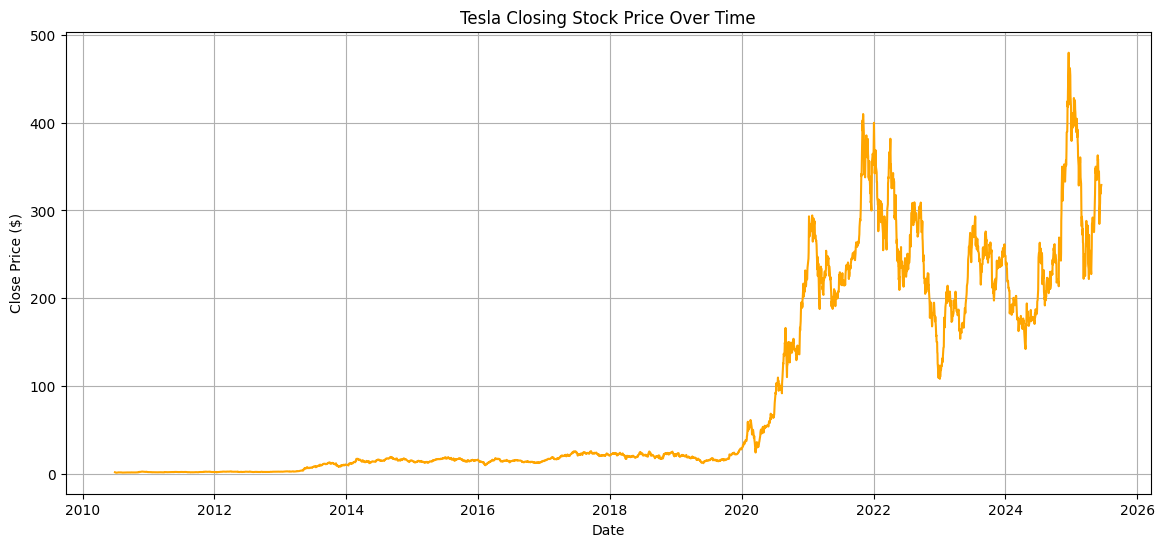

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
plt.plot(df['Close'], color='orange')
plt.title('Tesla Closing Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid()
plt.show()

# Feature Engineering for Visualization

In [9]:
import warnings
warnings.filterwarnings("ignore")

# Daily range: High - Low
df['Daily_Range'] = df['High'] - df['Low']

# 30-day moving average of closing price
df['MA_30'] = df['Close'].rolling(window=30).mean()

# Daily return as % change in close price
df['Daily_Return'] = df['Close'].pct_change() * 100

# Preview the new features
df[['Close', 'Daily_Range', 'MA_30', 'Daily_Return']].head()


,Close,Daily_Range,MA_30,Daily_Return
Date,,,,
2010-06-29,1.592667,0.497334,NaN,NaN
2010-06-30,1.588667,0.474667,NaN,-0.251148
2010-07-01,1.464000,0.376667,NaN,-7.847274
2010-07-02,1.280000,0.292667,NaN,-12.568307
2010-07-06,1.074000,0.278000,NaN,-16.093748


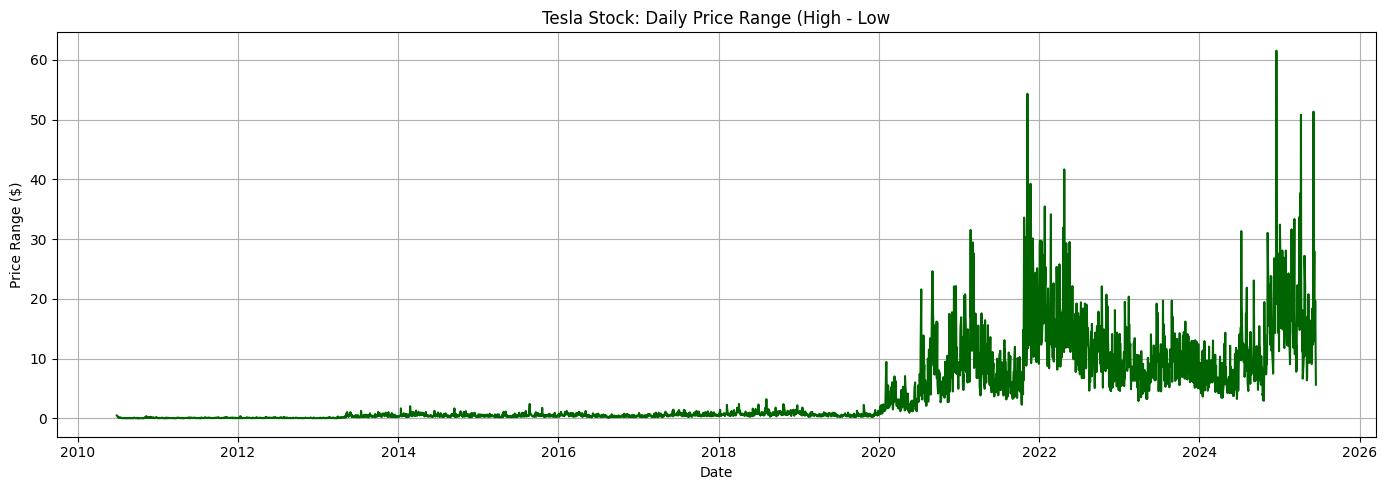

In [10]:
# Daily Price Range

plt.figure(figsize=(14,5))
plt.plot(df['Daily_Range'], color='darkgreen')
plt.title('Tesla Stock: Daily Price Range (High - Low')
plt.xlabel('Date')
plt.ylabel('Price Range ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

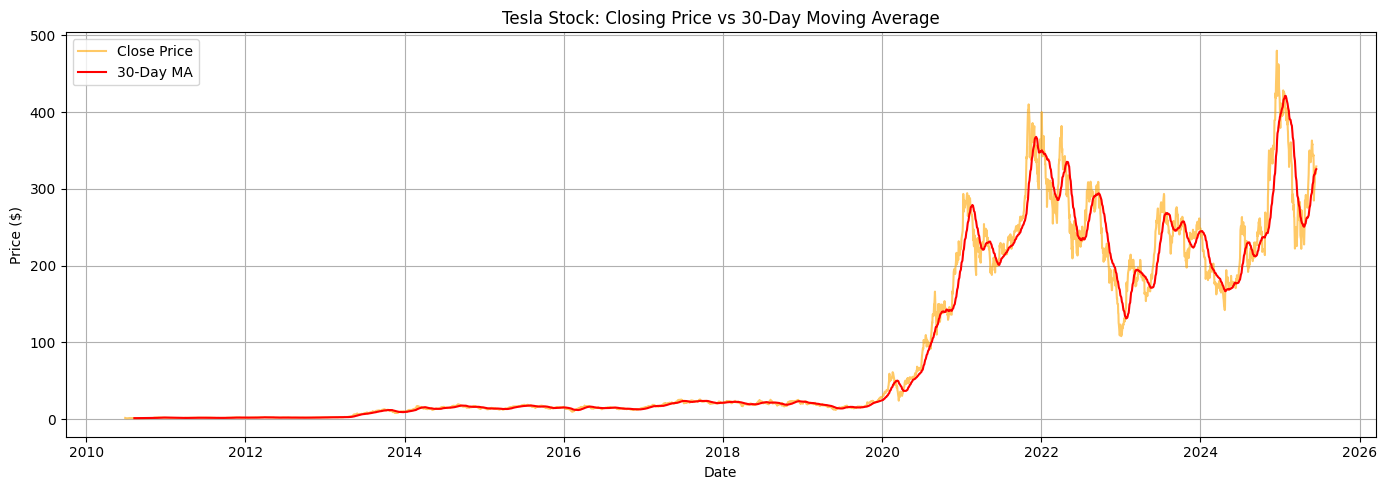

In [11]:
# 30 Day moving Average vs Closing Price

plt.figure(figsize=(14,5))
plt.plot(df['Close'], label='Close Price', alpha=0.6, color='orange')
plt.plot(df['MA_30'], label='30-Day MA', color='red')
plt.title('Tesla Stock: Closing Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

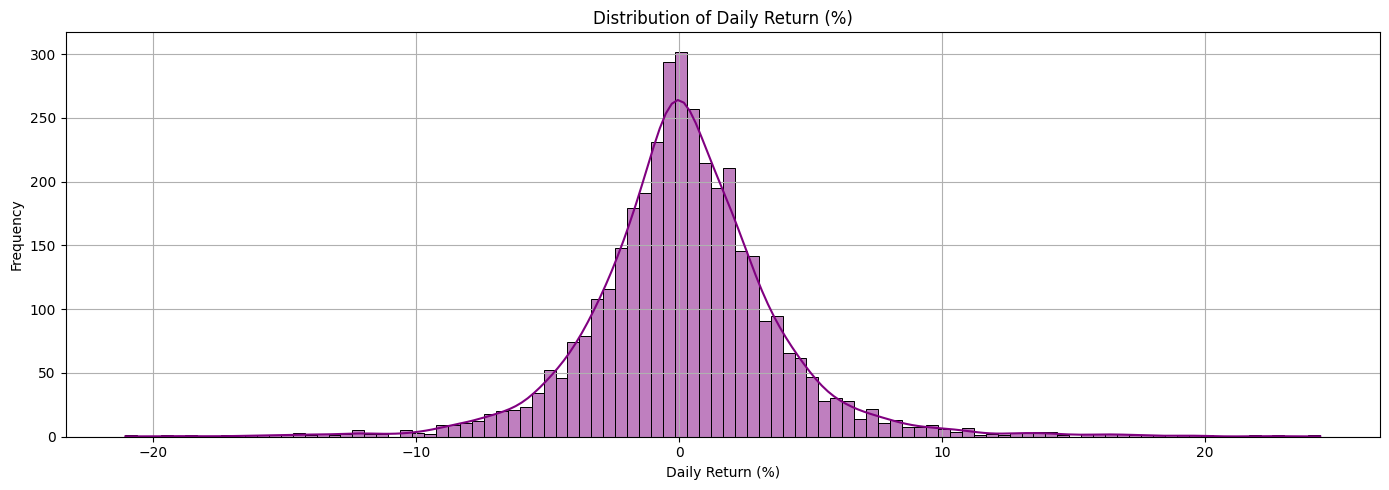

In [12]:
# Distribution of daily Returns

plt.figure(figsize=(14,5))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Return (%)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ['Open', 'High', 'Low', 'Volume']
target = 'Close'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'R2 Score : {r2:.4f}')

RMSE: 2.1273
R2 Score : 0.9996


In [14]:
import joblib

joblib.dump(model, 'tesla_stock_model.pkl')

['tesla_stock_model.pkl']